# SWaT Experiments

## Load Data

In [1]:
# Load swat data
from bdm.Experiments.data_loader import swat_data

train_df, test_df, signal_variables, control_variables, dict_continuous_variables, dict_discrete_variables = swat_data()
train_df = train_df.drop(["Timestamp", "Normal/Attack"], axis=1)
print(train_df.values.shape, test_df.values.shape)

(99360, 51) (89984, 54)


In [6]:
# Prepare data for RS
import numpy as np

x = train_df.values

train_mean = np.mean(x, axis=0, keepdims=True)
train_std = np.std(x, axis=0, keepdims=True)
train_std[train_std == 0] = 1

x -= train_mean
x /= train_std

x = np.nan_to_num(x, nan=0)

# Used 480 for some reason
x_esn_fit = x[:1200]
x_rhy_fit = x[480-100-200-100:480+200]

## Find hyperparams

In [3]:
# Find hp

from rhythmic_sharing import RhythmicNetwork

from tqdm import tqdm
import numpy as np

best_mse = np.inf

for iw in np.linspace(0.1, 0.2, 10): # np.linspace(0.1, 0.5, 10):
    network = RhythmicNetwork(
        # Tune Rhythmic Sharing
        dt=10,
        input_dims=x.shape[1],
        spectral_radius=0.5,
        input_weight=iw,
        average_degree_nodes=8,
        num_nodes=768, #512,
        leakage=0,
        # Rhythmic params
        link_strength_change_ratio=0
    )
    
    for sr in tqdm(np.linspace(0.1, 0.2, 10)): # tqdm(np.linspace(0.1, 0.5, 10)):
        for l in np.linspace(0.4, 0.5, 10): # np.linspace(0.25, 0.5, 10):
            network.change_spectral_rad_and_leakage(sr, l)

            network.train(x_esn_fit.T[:, :-200])
            pred = network.predict(x_esn_fit.T[:, -300:], warmup_time=100)
            mse = np.mean(np.square((pred[:, 1:] - x_esn_fit.T[:, -200:]))) # /np.std(pred[:, 1:], axis=1, keepdims=True)))
            if mse > 100_000_000:
                network.lsqrs = not network.lsqrs
        
            if mse < best_mse:
                print("New best %.10f" % mse, (sr, iw, l))
                best_esn_param = (sr, iw, l)
                best_mse = mse

  0%|                                                                                           | 0/10 [00:02<?, ?it/s]


KeyboardInterrupt: 

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

Switching to lsqr
New best 0.0005427189 (np.float64(0.25), np.float64(-0.1), np.float64(0.3), np.float64(0.01))


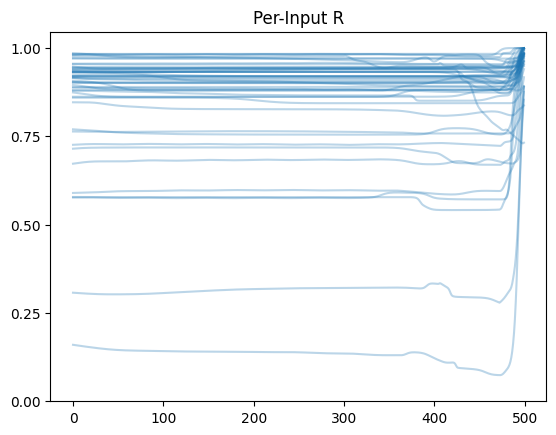

New best 0.0012077087 (np.float64(0.25), np.float64(-0.1), np.float64(0.37777777777777777), np.float64(0.01))


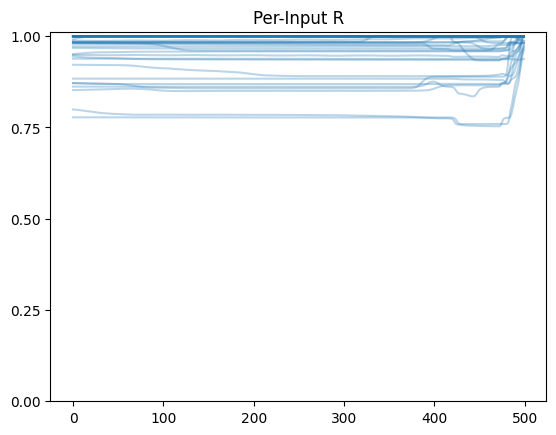

New best 0.0059087482 (np.float64(0.25), np.float64(-0.1), np.float64(0.5333333333333333), np.float64(0.01))


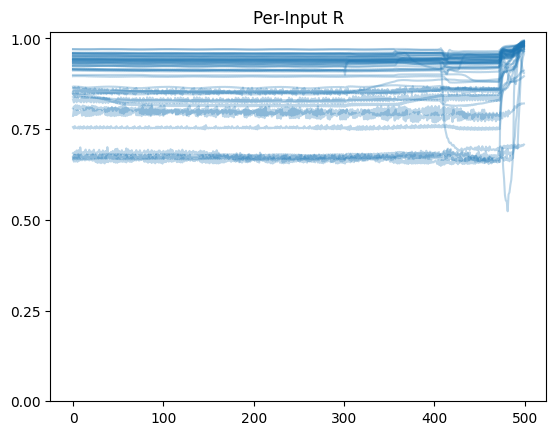

 10%|███████▉                                                                       | 1/10 [23:37<3:32:38, 1417.65s/it]

New best 0.0128454439 (np.float64(0.25), np.float64(-0.11111111111111112), np.float64(0.6111111111111112), np.float64(0.01))


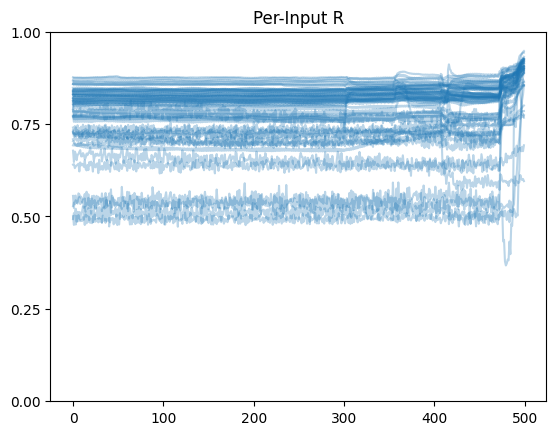

 50%|██████████████████████████████████████▌                                      | 5/10 [1:58:43<1:58:23, 1420.67s/it]

New best 0.0132210827 (np.float64(0.25), np.float64(-0.15555555555555556), np.float64(0.6888888888888889), np.float64(0.01))


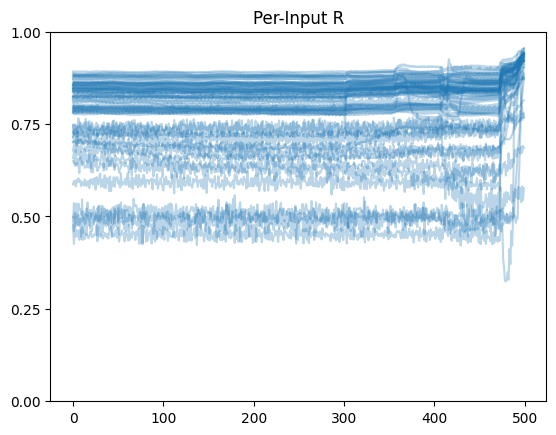

New best 0.0134143040 (np.float64(0.3333333333333333), np.float64(-0.15555555555555556), np.float64(0.6888888888888889), np.float64(0.01))


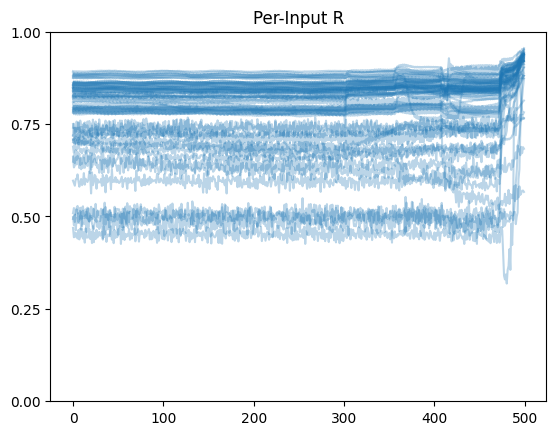

New best 0.0137126188 (np.float64(0.41666666666666663), np.float64(-0.15555555555555556), np.float64(0.6888888888888889), np.float64(0.01))


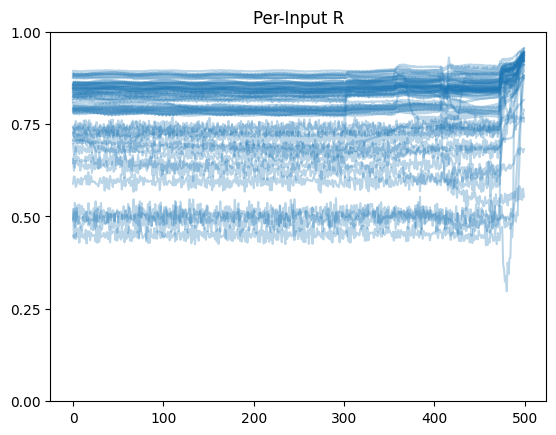

 90%|███████████████████████████████████████████████████████████████████████        | 9/10 [3:32:54<23:35, 1415.16s/it]

New best 0.0149859789 (np.float64(0.25), np.float64(-0.2), np.float64(0.7666666666666666), np.float64(0.01))


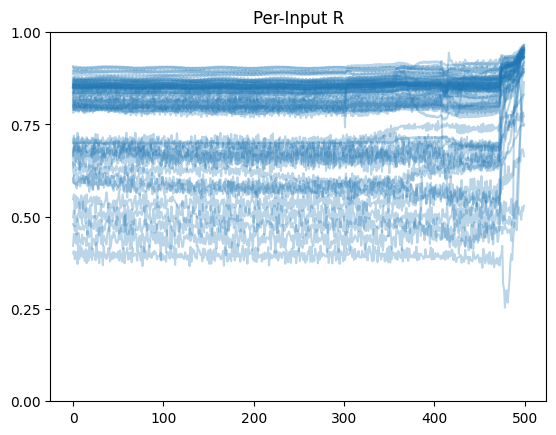

New best 0.0151571701 (np.float64(0.3333333333333333), np.float64(-0.2), np.float64(0.7666666666666666), np.float64(0.01))


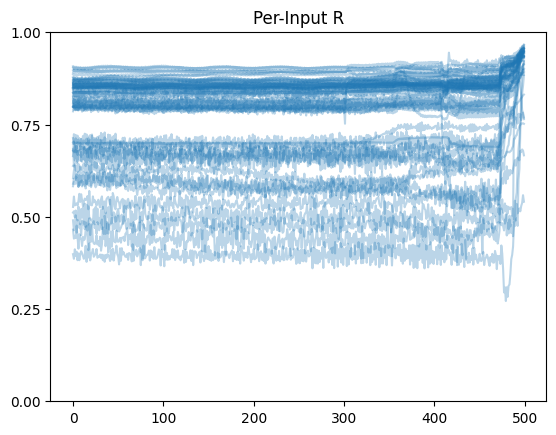

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

Switching to lsqr


 90%|███████████████████████████████████████████████████████████████████████        | 9/10 [3:23:56<22:33, 1353.98s/it]

New best 0.0152857180 (np.float64(0.3333333333333333), np.float64(-0.2), np.float64(0.7666666666666666), np.float64(0.05333333333333334))


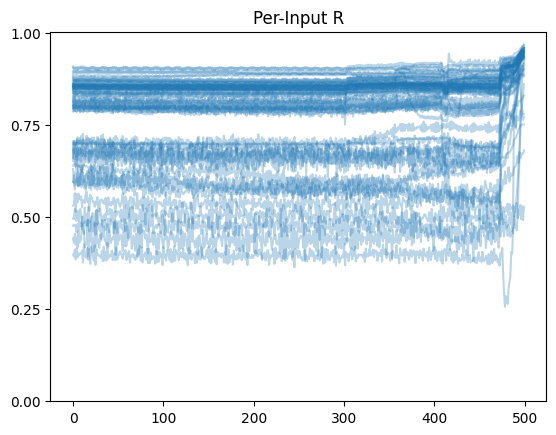

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

Switching to lsqr


  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

Switching to lsqr


 30%|███████████████████████                                                      | 3/10 [1:19:17<3:05:00, 1585.76s/it]


KeyboardInterrupt: 

In [5]:
import matplotlib.pyplot as plt

best_difference = 0

for o in np.linspace(0.01, 0.4, 10): # np.linspace(0.25, 0.35, 10):
    network = RhythmicNetwork(
        # Tune Rhythmic Sharing
        dt=10,
        input_dims=x.shape[1],
        spectral_radius=best_esn_param[0],
        input_weight=best_esn_param[1],
        average_degree_nodes=8,
        num_nodes=768,
        leakage=best_esn_param[2],
        # Rhythmic params
        link_strength_change_ratio=0,
        omega0=o,
        epsilon1=0,
        epsilon2=0,
    )
    
    for e1 in tqdm(np.linspace(-0.2, -0.1, 10)[::-1]): #tqdm(np.linspace(-0.15, -0.06, 10)[::-1]):
        for lsr in np.linspace(0.25, 1, 10): # np.linspace(0.8, 1, 10):
            for e2 in np.linspace(0.3, 1.0, 10): # np.linspace(0.5, .7, 10):
                network.epsilon1 = e1
                network.epsilon2 = e2
                network.link_strength_change_ratio = lsr
                network.reset_initial_states()
                network.reset_history()
                
                network.train(x_rhy_fit.T, warmup_time=100)
                r = network.get_global_parameters()[0]
    
                # diff = np.std(r.T[:200])/np.std(r.T[-200:])
                diff = np.abs(np.mean(r.T[-400:-200]) - np.mean(r.T[-200:])) #/np.mean(r.T[:250])
                
                if diff > best_difference and np.mean(r.T[-400:-200]) > 0.75: # np.mean(network.get_input_parameters()[0].T[75:100, 11]) > 0.5: # and np.mean(network.get_input_parameters()[0].T[75:100, 15]) > 0.5:
                    print("New best %.10f" % diff, (lsr, e1, e2, o))
                    best_param_rhy = (lsr, e1, e2, o)
                    best_difference = diff
    
                    plt.title("Per-Input R")
                    plt.plot(network.get_input_parameters()[0].T, color="tab:blue", alpha=0.3)
                    plt.yticks([0, 0.25, 0.5, 0.75, 1])
                    plt.show()

In [4]:
# Presaved params

best_esn_param = (0.19, 0.1, 0.41) # (0.14, 0.1, 0.4) # best_esn_param = (0.14, 0.1, 0.42) # best_esn_param = (0.37, 0.32, 0.44)
best_param_rhy = (0.75, -0.19, 0.77, 0.01) # best_param_rhy = (0.82, -0.15, 0.7, 0.31) # best_param_rhy = (0.83, -0.11, 0.63, 0.29) # best_param_rhy = (1.0, -0.1, 0.53, 0.31)

## Run data through RS

In [7]:
# Run network on train_df
from scipy.ndimage import median_filter

network = RhythmicNetwork(
    # Tune Rhythmic Sharing
    dt=10,
    input_dims=x.shape[1],
    spectral_radius=best_esn_param[0],
    input_weight=best_esn_param[1],
    average_degree_nodes=8,
    num_nodes=768,
    leakage=best_esn_param[2],
    # Rhythmic params
    link_strength_change_ratio=best_param_rhy[0],
    omega0=best_param_rhy[3],
    epsilon1=best_param_rhy[1],
    epsilon2=best_param_rhy[2],
)

network.train(x.T)
train_r = network.get_input_parameters()[0].T
# train_r = median_filter(train_r, size=16, axes=[0])
assert np.max(train_r, axis=0, keepdims=True).shape[1] == x.shape[1]
train_r = (train_r - np.min(train_r, axis=0, keepdims=True))/(np.max(train_r, axis=0, keepdims=True) - np.min(train_r, axis=0, keepdims=True))

100%|████████████████████████████████████████████████████████████████████████████| 99360/99360 [40:31<00:00, 40.87it/s]


In [33]:
# Load test_df
x = test_df.values[:, 1:-2].astype(float)

x -= train_mean
x /= train_std

x = np.nan_to_num(x, nan=0)
test_x_driftbench = x
x.shape

(89984, 51)

In [9]:
# Run network on test_df
network = RhythmicNetwork(
    # Tune Rhythmic Sharing
    dt=10,
    input_dims=x.shape[1],
    spectral_radius=best_esn_param[0],
    input_weight=best_esn_param[1],
    average_degree_nodes=8,
    num_nodes=768,
    leakage=best_esn_param[2],
    # Rhythmic params
    link_strength_change_ratio=best_param_rhy[0],
    omega0=best_param_rhy[3],
    epsilon1=best_param_rhy[1],
    epsilon2=best_param_rhy[2],
)

network.train(x.T)
test_r = network.get_input_parameters()[0].T
# test_r = median_filter(test_r, size=16, axes=[0])
assert np.max(test_r, axis=0, keepdims=True).shape[1] == x.shape[1]
test_r = (test_r - np.min(test_r, axis=0, keepdims=True))/(np.max(test_r, axis=0, keepdims=True) - np.min(test_r, axis=0, keepdims=True))

100%|████████████████████████████████████████████████████████████████████████████| 89984/89984 [36:40<00:00, 40.89it/s]


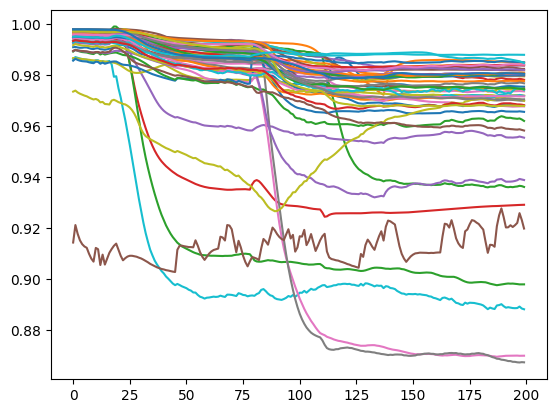

In [10]:
# Plot example from test
import matplotlib.pyplot as plt

plt.plot(test_r[919:1119])
plt.show()

## BDM

In [11]:
# Train bdm
# import keras
# keras.config.set_backend("tensorflow")

import bdm.Algorithm.BDM as new_bdm
import pandas as pd

new_train_df = pd.DataFrame(train_r, columns=train_df.columns).astype(float)

xl = 8
ul = xl * 2
batch_size = 256
bdm = new_bdm.BDM(x_length=xl, u_length=ul)
epochs = 250

x_prev, x_curr, x_next, u_curr, _ = bdm.prepare_data(
    new_train_df, signal_variables=signal_variables,
    control_variables=control_variables, dict_continuous_variables=dict_continuous_variables,
    dict_discrete_variables=dict_discrete_variables, label=None, normalization=None, freq=1
)

x_dim = int(x_curr.shape[1]/xl)
index = np.arange(len(x_prev))
train_pos = index[:(len(x_prev) * 3 // 4)]
val_pos = index[(len(x_prev) * 3 // 4):]

x_train_bdm = [x_prev[train_pos, :], x_curr[train_pos, :], x_next[train_pos, :], u_curr[train_pos, :]]
x_val_bdm = [x_prev[val_pos, :], x_curr[val_pos, :], x_next[val_pos, :], u_curr[val_pos, :]]

bdm.train(x_train_bdm, s_dim=4, s_activation='tanh', batch_size=batch_size, epochs=epochs, validation_split=0.1, verbose=2)

Epoch 1/250
262/262 - 19s - 72ms/step - functional_1_loss: 0.3463 - functional_loss: 0.2459 - loss: 1.0666 - subtract_1_loss: 0.0428 - subtract_loss: 0.0379 - val_functional_1_loss: 0.0228 - val_functional_loss: 0.2695 - val_loss: 0.1019 - val_subtract_1_loss: 0.0079 - val_subtract_loss: 0.0086
Epoch 2/250
262/262 - 5s - 18ms/step - functional_1_loss: 0.0085 - functional_loss: 0.1560 - loss: 0.0449 - subtract_1_loss: 0.0088 - subtract_loss: 0.0116 - val_functional_1_loss: 0.0023 - val_functional_loss: 0.0770 - val_loss: 0.0166 - val_subtract_1_loss: 0.0046 - val_subtract_loss: 0.0078
Epoch 3/250
262/262 - 5s - 18ms/step - functional_1_loss: 0.0018 - functional_loss: 0.0421 - loss: 0.0107 - subtract_1_loss: 0.0035 - subtract_loss: 0.0044 - val_functional_1_loss: 6.7693e-04 - val_functional_loss: 0.0217 - val_loss: 0.0042 - val_subtract_1_loss: 0.0021 - val_subtract_loss: 0.0010
Epoch 4/250
262/262 - 5s - 18ms/step - functional_1_loss: 8.6576e-04 - functional_loss: 0.0108 - loss: 0.0043 

In [12]:
# Test bdm
from bdm.Algorithm.utils import f_search
from sklearn import metrics

bdm.estimate_system(x_val_bdm)

new_test_df = pd.DataFrame(
    np.concatenate([test_r, test_df.values[:, -1:]], axis=1),
    columns=list(test_df.columns[1:-2]) + [test_df.columns[-1]]
).astype(float)

_, x_curr, _, u_curr, labels = bdm.prepare_data(
    new_test_df, signal_variables=signal_variables,
    control_variables=control_variables, dict_continuous_variables=dict_continuous_variables,
    dict_discrete_variables=dict_discrete_variables, label='label', normalization=None, freq=xl
)

test_x_bdm = x_curr; test_u_bdm = u_curr

z_scores_bdm = bdm.test(test_x_bdm, test_u_bdm)
z_scores_bdm = np.nan_to_num(z_scores_bdm)
t, _ = f_search(z_scores_bdm, labels[1:])

print('BDM')
print('best-f1', t[0]) # Before removing > 0.7, this was 0.75
print('precision', t[1])
print('recall', t[2])
print('accuracy', (t[3] + t[4]) / (t[3] + t[4] + t[5] + t[6]))
print('TP', t[3])
print('TN', t[4])
print('FP', t[5])
print('FN', t[6])
print('AUC:', metrics.roc_auc_score(labels[1:], z_scores_bdm))

777/777 ━━━━━━━━━━━━━━━━━━━━ 1s 940us/step
777/777 ━━━━━━━━━━━━━━━━━━━━ 1s 777us/step
777/777 ━━━━━━━━━━━━━━━━━━━━ 1s 772us/step
777/777 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
777/777 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
777/777 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
777/777 ━━━━━━━━━━━━━━━━━━━━ 1s 941us/step
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 875us/step
BDM
best-f1 0.763327089789021
precision 0.9730336969322056
recall 0.6279912934880979
accuracy 0.9522454424188528
TP 866.0
TN 9842.0
FP 24.0
FN 513.0
AUC: 0.8411763313682534


## NSIBF

In [13]:
# Setup NSIBF
import os, sys
sys.path.append(os.path.abspath("NSIBF"))

import NSIBF.framework.models as models
from NSIBF.framework.HPOptimizer.Hyperparameter import UniformIntegerHyperparameter,ConstHyperparameter, UniformFloatHyperparameter
from NSIBF.framework.HPOptimizer import HPOptimizers
from NSIBF.framework.preprocessing import normalize_and_encode_signals
from NSIBF.framework.preprocessing.signals import SignalSource, ContinousSignal
from NSIBF.framework.utils.metrics import bf_search
from NSIBF.framework.utils import negative_sampler

signals = []
for c in list(test_df.columns[1:-2]):
    signals.append(ContinousSignal(c, SignalSource.sensor, isInput=True, isOutput=True, min_value=0, max_value=1))

seqL = 12
kf = models.NSIBF(signals, window_length=seqL, input_range=seqL*3)

pos = len(new_train_df)*3//4
nsibf_val_df = new_train_df.loc[pos:,:]
nsibf_val_df = nsibf_val_df.reset_index(drop=True)

nsibf_train_df = new_train_df.loc[:pos,:]
nsibf_train_df = nsibf_train_df.reset_index(drop=True)

nsibf_train_df = normalize_and_encode_signals(nsibf_train_df, signals, scaler='min_max')
train_x,train_u,train_y,_ = kf.extract_data(nsibf_train_df)
x_train = [train_x,train_u]
y_train = [train_x,train_y]

x,u,y = [],[],[]
for i in range(20):
    r = 0.05*i
    negative_df = negative_sampler.apply_negative_samples(nsibf_val_df, signals, sample_ratio=r, sample_delta=0.05)
    negative_df = normalize_and_encode_signals(negative_df,signals,scaler='min_max')
    neg_x,neg_u,_,neg_labels = kf.extract_data(negative_df,purpose='AD',freq=seqL,label='class_label')
    neg_labels = neg_labels.sum(axis=1)
    neg_labels[neg_labels<seqL]=0
    neg_labels[neg_labels==seqL]=1
    x.append(neg_x)
    u.append(neg_u)
    y.append(neg_labels)
x = np.concatenate(x)
u = np.concatenate(u)
y = np.concatenate(y)
print(list(y).count(1),len(y))
x_neg = [x,u]
y_neg = y

4561 41360


In [14]:
# Train NSIBF

hp_list = []
hp_list.append(UniformIntegerHyperparameter('z_dim',1,75)) 
hp_list.append(UniformIntegerHyperparameter('hnet_hidden_layers',1,3))  
hp_list.append(UniformIntegerHyperparameter('fnet_hidden_layers',1,3))
hp_list.append(UniformIntegerHyperparameter('fnet_hidden_dim',32,256))
hp_list.append(UniformIntegerHyperparameter('uencoding_layers',1,3))
hp_list.append(UniformIntegerHyperparameter('uencoding_dim',32,256))
hp_list.append(UniformFloatHyperparameter('l2',0,0.05))
hp_list.append(ConstHyperparameter('epochs',25))
hp_list.append(ConstHyperparameter('save_best_only',True))
hp_list.append(ConstHyperparameter('validation_split',0.1))
hp_list.append(ConstHyperparameter('batch_size',256*8))
hp_list.append(ConstHyperparameter('verbose',2))

optor = HPOptimizers.RandomizedGS(kf, hp_list,x_train, y_train,x_neg,y_neg)
kf,optHPCfg,bestScore = optor.run(n_searches=10,verbose=1)


Epoch 1/25
33/33 - 9s - 274ms/step - h_net_loss: 0.5378 - loss: 95.6369 - smoothing_loss: 0.0331 - val_h_net_loss: 0.0940 - val_loss: 2.2583 - val_smoothing_loss: 7.4091e-04
Epoch 2/25
33/33 - 5s - 156ms/step - h_net_loss: 0.0212 - loss: 0.8266 - smoothing_loss: 2.6685e-04 - val_h_net_loss: 5.2573e-04 - val_loss: 0.1012 - val_smoothing_loss: 3.4288e-05
Epoch 3/25
33/33 - 5s - 156ms/step - h_net_loss: 0.0016 - loss: 0.1861 - smoothing_loss: 6.2297e-05 - val_h_net_loss: 6.9359e-04 - val_loss: 0.0468 - val_smoothing_loss: 1.7359e-05
Epoch 4/25
33/33 - 5s - 156ms/step - h_net_loss: 0.0011 - loss: 0.1412 - smoothing_loss: 4.7082e-05 - val_h_net_loss: 2.1431e-04 - val_loss: 0.0433 - val_smoothing_loss: 1.6074e-05
Epoch 5/25
33/33 - 5s - 153ms/step - h_net_loss: 0.0010 - loss: 0.1239 - smoothing_loss: 4.1589e-05 - val_h_net_loss: 2.2735e-04 - val_loss: 0.0420 - val_smoothing_loss: 1.5602e-05
Epoch 6/25
33/33 - 5s - 156ms/step - h_net_loss: 0.0010 - loss: 0.1096 - smoothing_loss: 3.6890e-05 -

score: 0.6096729862646932 {'z_dim': 50, 'hnet_hidden_layers': 2, 'fnet_hidden_layers': 2, 'fnet_hidden_dim': 208, 'uencoding_layers': 1, 'uencoding_dim': 47, 'l2': 0.028152046578265102, 'epochs': 25, 'save_best_only': True, 'validation_split': 0.1, 'batch_size': 2048, 'verbose': 2}
Epoch 1/25
33/33 - 59s - 2s/step - h_net_loss: 0.6217 - loss: 22.4070 - smoothing_loss: 0.6910 - val_h_net_loss: 0.1359 - val_loss: 19.8160 - val_smoothing_loss: 0.6815
Epoch 2/25
33/33 - 55s - 2s/step - h_net_loss: 0.0221 - loss: 20.8356 - smoothing_loss: 0.6630 - val_h_net_loss: 0.0021 - val_loss: 19.5883 - val_smoothing_loss: 0.6636
Epoch 3/25
33/33 - 53s - 2s/step - h_net_loss: 0.0019 - loss: 20.7892 - smoothing_loss: 0.6629 - val_h_net_loss: 3.2748e-04 - val_loss: 19.5810 - val_smoothing_loss: 0.6604
Epoch 4/25
33/33 - 82s - 2s/step - h_net_loss: 0.0012 - loss: 20.8948 - smoothing_loss: 0.6661 - val_h_net_loss: 3.0637e-04 - val_loss: 19.5821 - val_smoothing_loss: 0.6599
Epoch 5/25
33/33 - 54s - 2s/step 

score: 0.6212646115878612 {'z_dim': 3, 'hnet_hidden_layers': 2, 'fnet_hidden_layers': 3, 'fnet_hidden_dim': 245, 'uencoding_layers': 2, 'uencoding_dim': 232, 'l2': 0.005087528252742602, 'epochs': 25, 'save_best_only': True, 'validation_split': 0.1, 'batch_size': 2048, 'verbose': 2}
Epoch 1/25
33/33 - 28s - 844ms/step - h_net_loss: 0.5636 - loss: 195.9988 - smoothing_loss: 0.0327 - val_h_net_loss: 0.0980 - val_loss: 3.0970 - val_smoothing_loss: 5.6984e-04
Epoch 2/25
33/33 - 24s - 735ms/step - h_net_loss: 0.0181 - loss: 0.9948 - smoothing_loss: 1.6518e-04 - val_h_net_loss: 6.2287e-04 - val_loss: 0.1486 - val_smoothing_loss: 2.6873e-05
Epoch 3/25
33/33 - 24s - 719ms/step - h_net_loss: 0.0015 - loss: 0.1863 - smoothing_loss: 3.2675e-05 - val_h_net_loss: 3.2865e-04 - val_loss: 0.0554 - val_smoothing_loss: 1.0233e-05
Epoch 4/25
33/33 - 23s - 698ms/step - h_net_loss: 0.0013 - loss: 0.1505 - smoothing_loss: 2.6504e-05 - val_h_net_loss: 2.6748e-04 - val_loss: 0.0512 - val_smoothing_loss: 9.4202

score: 0.6222510686424916 {'z_dim': 47, 'hnet_hidden_layers': 1, 'fnet_hidden_layers': 1, 'fnet_hidden_dim': 220, 'uencoding_layers': 1, 'uencoding_dim': 156, 'l2': 0.0037324270561966025, 'epochs': 25, 'save_best_only': True, 'validation_split': 0.1, 'batch_size': 2048, 'verbose': 2}


In [ ]:
# Test NSIBF

nsibf_val_df = normalize_and_encode_signals(nsibf_val_df, signals, scaler='min_max') 
val_x,val_u,val_y,_ = kf.extract_data(nsibf_val_df)

nsibf_test_df = normalize_and_encode_signals(new_test_df,signals,scaler='min_max')
test_x,test_u,_,labels = kf.extract_data(nsibf_test_df, purpose='AD', freq=seqL,label='label')
labels = labels.sum(axis=1)
labels[labels>0]=1

kf.estimate_noise(val_x,val_u,val_y)

z_scores = kf.score_samples(test_x, test_u,reset_hidden_states=True)
# np.savetxt('../results/SWAT/NSIBF_scores',z_scores)
# z_scores = np.loadtxt('../results/SWAT/NSIBF_scores')
recon_scores,pred_scores = kf.score_samples_via_residual_error(test_x,test_u)

z_scores = np.nan_to_num(z_scores)

775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 879us/step
775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 715us/step
775/775 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step
775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 759us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
2 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
3 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
6 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
7 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
8 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
9 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
10 / 7496
3/3 ━━━━━━━━━━━━━

C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\spatial\distance.py:1136: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(m)


516 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
517 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
518 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
519 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
520 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
521 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
522 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
523 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
524 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
525 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
526 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
527 / 7496
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms

In [19]:
t, th = bf_search(z_scores, labels[1:],start=0,end=np.percentile(z_scores,99.9),step_num=10000,display_freq=50,verbose=False)
print('NSIBF')
print('best-f1', t[0])
print('precision', t[1])
print('recall', t[2])
print('accuracy',(t[3]+t[4])/(t[3]+t[4]+t[5]+t[6]))
print('TP', t[3])
print('TN', t[4])
print('FP', t[5])
print('FN', t[6])
print()
 
t, th = bf_search(recon_scores[1:], labels[1:],start=0,end=np.percentile(recon_scores,99.9),step_num=10000,display_freq=50,verbose=False)
print('NSIBF-RECON')
print('best-f1', t[0])
print('precision', t[1])
print('recall', t[2])
print('accuracy',(t[3]+t[4])/(t[3]+t[4]+t[5]+t[6]))
print('TP', t[3])
print('TN', t[4])
print('FP', t[5])
print('FN', t[6])
print()
 
t, th = bf_search(pred_scores, labels[1:],start=0,end=np.percentile(pred_scores,99.9),step_num=10000,display_freq=50,verbose=False)
print('NSIBF-PRED')
print('best-f1', t[0])
print('precision', t[1])
print('recall', t[2])
print('accuracy',(t[3]+t[4])/(t[3]+t[4]+t[5]+t[6]))
print('TP', t[3])
print('TN', t[4])
print('FP', t[5])
print('FN', t[6])
print()

# del nsibf_test_df, nsibf_train_df, nsibf_val_df, train_x, train_u, train_y, val_x, val_u, val_y, kf, HPOptimizers

NSIBF
best-f1 0.8268838074427994
precision 0.9291443726050218
recall 0.7449088880502799
accuracy 0.9611741160773849
TP 695.0
TN 6509.0
FP 53.0
FN 238.0

NSIBF-RECON
best-f1 0.8441109365845593
precision 0.9927536088006724
recall 0.7341907745531535
accuracy 0.9662441627751834
TP 685.0
TN 6557.0
FP 5.0
FN 248.0

NSIBF-PRED
best-f1 0.8163473416766804
precision 0.9878234248428703
recall 0.6956055659634988
accuracy 0.9610406937958639
TP 649.0
TN 6554.0
FP 8.0
FN 284.0



## Driftbench

In [48]:
# Test using driftbench
from drift_helpers import added_detectors 
from drift_helpers import added_metrics

from driftbench.drift_detection.detectors import (
    RandomGuessDetector,
    RollingMeanDifferenceDetector,
    RollingMeanStandardDeviationDetector,
    AggregateFeatureAlgorithm,
    SlidingKSWINDetector,
    ClusterDetector,
    AutoencoderDetector,
    MMDDetector,
)
from driftbench.drift_detection.metrics import (
    TemporalAUC,
    SoftTAUC,
    AUC,
)

from river.drift import ADWIN, KSWIN, PageHinkley

detectors = [
    # Detectors from driftbench
    AutoencoderDetector(
        hidden_layers=[150, 120, 80, 50, 20, 10, 8],
        retrain_always=True,
        detector=AggregateFeatureAlgorithm(
            agg_feature_func=np.mean,
            algorithm=SlidingKSWINDetector(window_size=20, stat_size=20, offset=10),
        ),
        num_epochs=100,
        batch_size=200,
        lr=0.001,
    ),
    AutoencoderDetector(
        hidden_layers=[150, 120, 80, 50, 20, 10, 8],
        retrain_always=True,
        detector=MMDDetector(window_size=20, stat_size=20, offset=10),
        num_epochs=100,
        batch_size=200,
        lr=0.001,
    ),
    AutoencoderDetector(
        hidden_layers=[120, 80, 50, 20, 10, 8],
        retrain_always=True,
        detector=AggregateFeatureAlgorithm(
            agg_feature_func=np.mean,
            algorithm=SlidingKSWINDetector(window_size=20, stat_size=20, offset=10),
        ),
        num_epochs=100,
        batch_size=200,
        lr=0.001,
    ),
    AutoencoderDetector(
        hidden_layers=[120, 80, 50, 20, 10, 8],
        retrain_always=True,
        detector=MMDDetector(window_size=20, stat_size=20, offset=10),
        num_epochs=100,
        batch_size=200,
        lr=0.001,
    ),
    MMDDetector(window_size=20, stat_size=20, offset=10),
    MMDDetector(window_size=30, stat_size=30, offset=10),
    MMDDetector(window_size=40, stat_size=40, offset=10),
    MMDDetector(window_size=50, stat_size=50, offset=10),
    RollingMeanDifferenceDetector(window_size=20),
    RollingMeanDifferenceDetector(window_size=30),
    RollingMeanDifferenceDetector(window_size=40),
    RollingMeanDifferenceDetector(window_size=50),
    RollingMeanStandardDeviationDetector(window_size=20),
    RollingMeanStandardDeviationDetector(window_size=30),
    RollingMeanStandardDeviationDetector(window_size=40),
    RollingMeanStandardDeviationDetector(window_size=50),
    ClusterDetector(n_centers=15, method="kmeans"),
    ClusterDetector(n_centers=15, method="gaussian mixture"),
    ClusterDetector(n_centers=10, method="kmeans"),
    ClusterDetector(n_centers=10, method="gaussian mixture"),
    ClusterDetector(n_centers=5, method="kmeans"),
    ClusterDetector(n_centers=5, method="gaussian mixture")
]

f1_score = added_metrics.F1_Score()
metrics = [
    f1_score,
    added_metrics.Precision(f1_metric_obj=f1_score),
    added_metrics.Recall(f1_metric_obj=f1_score),
    added_metrics.Delay(f1_metric_obj=f1_score),
    added_metrics.EarlyDetect(f1_metric_obj=f1_score),
    added_metrics.Accuracy(f1_metric_obj=f1_score),
    # TemporalAUC(rule='step'),
    # TemporalAUC(rule='trapez'),
    # SoftTAUC(rule='step'),
    # AUC(),
]

output = []


db_train_y = test_df["label"].values[:(len(test_r)//5)*4]
db_test_y = test_df["label"].values[(len(test_r)//5)*4:]

for detector in tqdm(detectors):
    db_train_pred = detector.predict(test_x_driftbench)
    db_test_pred = db_train_pred[(len(test_r)//5)*4:]
    db_train_pred = db_train_pred[:(len(test_r)//5)*4:]

    db_train_pred_r = detector.predict(test_r)
    db_test_pred_r = db_train_pred_r[(len(test_r)//5)*4:]
    db_train_pred_r = db_train_pred_r[:(len(test_r)//5)*4]

    try:
        f1_score(db_train_pred, db_train_y)
        pred_thresh = f1_score.thresh
        f1_score(db_train_pred_r, db_train_y)
        pred_r_thresh = f1_score.thresh
        
        try:
            output.append({
                "sample": i,
                "detector": detector.name,
                "params": detector.get_hparams(),
                "generic_metrics": {
                    metric.name: metric(db_test_pred, db_test_y, set_threshold=pred_thresh) for metric in metrics
                },
                "r_metrics": {
                    metric.name: metric(db_test_pred_r, db_test_y, set_threshold=pred_r_thresh) for metric in metrics
                }
            })
        except TypeError:
            output.append({
                "sample": i,
                "detector": detector.name,
                "params": detector.get_hparams(),
                "generic_metrics": {
                    metric.name: metric(db_test_pred, db_test_y) for metric in metrics
                },
                "r_metrics": {
                    metric.name: metric(db_test_pred_r, db_test_y) for metric in metrics
                }
            })
    except ValueError:
        pass
    except RuntimeError:
        print("RE", detector.name)
    

100%|███████████████████████████████████████████████████████████████████████████████| 22/22 [1:03:05<00:00, 172.06s/it]


In [49]:
# Separate f1 scores by detector and whether using RS
separated_output = {}
for result in output:
    params = ",".join("%s:%s" % (k, v) for k, v in result["params"].items())
    separated_output[result["detector"] + "," + params] = separated_output.get(result["detector"] + "," + params, {
        "generic": [],
        "rs": []
    })

    separated_output[result["detector"] + "," + params]["generic"].append(result["generic_metrics"])
    separated_output[result["detector"] + "," + params]["rs"].append(result["r_metrics"])

print(separated_output[result["detector"] + "," + params]["rs"][0].keys())

for k, v in separated_output.items():
    print(k, np.nanmean([i["EarlyDetect"] for i in v["generic"]]), np.nanmean([i["EarlyDetect"] for i in v["rs"]]))
    print(k, np.nanmean([i["Delay"] for i in v["generic"]]), np.nanmean([i["Delay"] for i in v["rs"]]))
    print(k, np.nanmean([i["F1_Score"] for i in v["generic"]]), np.nanmean([i["F1_Score"] for i in v["rs"]]))
    print(k, np.nanmean([i["Precision"] for i in v["generic"]]), np.nanmean([i["Precision"] for i in v["rs"]]))
    print(k, np.nanmean([i["Recall"] for i in v["generic"]]), np.nanmean([i["Recall"] for i in v["rs"]]))
    print(k, np.nanmean([i["Accuracy"] for i in v["generic"]]), np.nanmean([i["Accuracy"] for i in v["rs"]]))
    print("======")

dict_keys(['F1_Score', 'Precision', 'Recall', 'Delay', 'EarlyDetect', 'Accuracy'])
AutoencoderDetector,activation:tanh,lr:0.001,optim:adam,num_epochs:100,hidden_layers:[150, 120, 80, 50, 20, 10, 8] 21.857142857142858 935.9027777777778
AutoencoderDetector,activation:tanh,lr:0.001,optim:adam,num_epochs:100,hidden_layers:[150, 120, 80, 50, 20, 10, 8] 0.8333333333333333 0.2777777777777778
AutoencoderDetector,activation:tanh,lr:0.001,optim:adam,num_epochs:100,hidden_layers:[150, 120, 80, 50, 20, 10, 8] 0.09596951050421235 0.10145164860049523
AutoencoderDetector,activation:tanh,lr:0.001,optim:adam,num_epochs:100,hidden_layers:[150, 120, 80, 50, 20, 10, 8] 0.05274715867222651 0.053463932562048844
AutoencoderDetector,activation:tanh,lr:0.001,optim:adam,num_epochs:100,hidden_layers:[150, 120, 80, 50, 20, 10, 8] 0.5878594249201278 0.9914802981895634
AutoencoderDetector,activation:tanh,lr:0.001,optim:adam,num_epochs:100,hidden_layers:[150, 120, 80, 50, 20, 10, 8] 0.957 0.9991111111111111
Autoenco

In [50]:
output

[{'sample': 19,
  'detector': 'AutoencoderDetector',
  'params': {'activation': 'tanh',
   'lr': 0.001,
   'optim': 'adam',
   'num_epochs': 100,
   'hidden_layers': [150, 120, 80, 50, 20, 10, 8]},
  'generic_metrics': {'F1_Score': np.float64(0.08336009247960953),
   'Precision': np.float64(0.04435483870967742),
   'Recall': np.float64(0.691160809371672),
   'Delay': np.float64(1.3333333333333333),
   'EarlyDetect': np.float64(18.714285714285715),
   'Accuracy': np.float64(0.9677777777777777)},
  'r_metrics': {'F1_Score': np.float64(0.09916046253762079),
   'Precision': np.float64(0.05216666666666667),
   'Recall': np.float64(1.0),
   'Delay': np.float64(0.0),
   'EarlyDetect': np.float64(1790.5555555555557),
   'Accuracy': np.float64(1.0)}},
 {'sample': 19,
  'detector': 'AutoencoderDetector',
  'params': {'activation': 'tanh',
   'lr': 0.001,
   'optim': 'adam',
   'num_epochs': 100,
   'hidden_layers': [150, 120, 80, 50, 20, 10, 8]},
  'generic_metrics': {'F1_Score': np.float64(0.10